# **Market Rate Prediction**

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np

**Load Dataset and Reading Data**

In [ ]:
import pandas as pd
df=pd.read_csv("supermarket.csv")
df.head(10) #show first 10 rows


,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,NaN,29.8865,627.6165,3/25/2019,18:30,Ewallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,A,Yangon,Member,Female,Electronic accessories,68.84,6.0,20.6520,433.6920,2/25/2019,14:36,Ewallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10.0,36.7800,772.3800,2/24/2019,11:38,Ewallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,A,Yangon,Member,Female,Health and beauty,36.26,2.0,3.6260,76.1460,1/10/2019,17:15,Credit card,72.52,4.761905,3.6260,7.2
9,692-92-5582,B,Mandalay,Member,Female,Food and beverages,54.84,3.0,8.2260,172.7460,2/20/2019,13:27,Credit card,164.52,4.761905,8.2260,5.9


**Data Information**

In [ ]:
df.info() # for showing column and their data type




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 966 non-null    float64
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  963 non-null    object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

**Missing Data**

In [ ]:
df.isnull().sum()


,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,34
Tax 5%,0
Total,0


**Handling of missing data**

In [ ]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())
df['Payment'] = df['Payment'].fillna(df['Payment'].mode()[0])
df.isnull().sum()


,0
Invoice ID,0
Branch,0
City,0
Customer type,0
Gender,0
Product line,0
Unit price,0
Quantity,0
Tax 5%,0
Total,0


**Data Transformation (date & time)**

In [ ]:
# Fix column names and extract Date & Time features
df.columns = df.columns.str.strip()   # remove extra spaces if any
df_transformed = df.copy()

# Convert Date column to datetime and extract features
df_transformed['Date'] = pd.to_datetime(df_transformed['Date'])
df_transformed['Day'] = df_transformed['Date'].dt.day
df_transformed['Month'] = df_transformed['Date'].dt.month

# Convert Time column to datetime and extract hour
df_transformed['Hour'] = pd.to_datetime(df_transformed['Time']).dt.hour

# Drop unused columns
df_transformed = df_transformed.drop(['Date','Time','Invoice ID'], axis=1)

df_transformed.head(10)


/tmp/ipython-input-815389042.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_transformed['Hour'] = pd.to_datetime(df_transformed['Time']).dt.hour


,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour
0,A,Yangon,Member,Female,Health and beauty,74.69,7.0,26.1415,548.9715,Ewallet,522.83,4.761905,26.1415,9.1,5,1,13
1,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5.0,3.8200,80.2200,Cash,76.40,4.761905,3.8200,9.6,8,3,10
2,A,Yangon,Normal,Male,Home and lifestyle,46.33,7.0,16.2155,340.5255,Credit card,324.31,4.761905,16.2155,7.4,3,3,13
3,A,Yangon,Member,Male,Health and beauty,58.22,8.0,23.2880,489.0480,Ewallet,465.76,4.761905,23.2880,8.4,27,1,20
4,A,Yangon,Normal,Male,Sports and travel,86.31,7.0,30.2085,634.3785,Ewallet,604.17,4.761905,30.2085,5.3,8,2,10
5,C,Naypyitaw,Normal,Male,Electronic accessories,85.39,5.0,29.8865,627.6165,Ewallet,597.73,4.761905,29.8865,4.1,25,3,18
6,A,Yangon,Member,Female,Electronic accessories,68.84,6.0,20.6520,433.6920,Ewallet,413.04,4.761905,20.6520,5.8,25,2,14
7,C,Naypyitaw,Normal,Female,Home and lifestyle,73.56,10.0,36.7800,772.3800,Ewallet,735.60,4.761905,36.7800,8.0,24,2,11
8,A,Yangon,Member,Female,Health and beauty,36.26,2.0,3.6260,76.1460,Credit card,72.52,4.761905,3.6260,7.2,10,1,17
9,B,Mandalay,Member,Female,Food and beverages,54.84,3.0,8.2260,172.7460,Credit card,164.52,4.761905,8.2260,5.9,20,2,13


**Data Normalized**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Copy transformed dataframe
df_normalized = df_transformed.copy()

# Select numeric columns to scale
num_cols = ['Unit price','Quantity','Tax 5%','Total','cogs','gross income']

# Apply MinMaxScaler (scales values between 0 and 1)
scaler = MinMaxScaler()
df_normalized[num_cols] = scaler.fit_transform(df_normalized[num_cols]) #to find every column max and min value

# Show first 10 rows of normalized data
df_normalized.head(10)


,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour
0,A,Yangon,Member,Female,Health and beauty,0.718847,0.666667,0.521616,0.521616,Ewallet,0.521616,4.761905,0.521616,9.1,5,1,13
1,C,Naypyitaw,Normal,Female,Electronic accessories,0.057855,0.444444,0.067387,0.067387,Cash,0.067387,4.761905,0.067387,9.6,8,3,10
2,A,Yangon,Normal,Male,Home and lifestyle,0.403316,0.666667,0.319628,0.319628,Credit card,0.319628,4.761905,0.319628,7.4,3,3,13
3,A,Yangon,Member,Male,Health and beauty,0.535603,0.777778,0.463549,0.463549,Ewallet,0.463549,4.761905,0.463549,8.4,27,1,20
4,A,Yangon,Normal,Male,Sports and travel,0.848131,0.666667,0.604377,0.604377,Ewallet,0.604377,4.761905,0.604377,5.3,8,2,10
5,C,Naypyitaw,Normal,Male,Electronic accessories,0.837895,0.444444,0.597825,0.597825,Ewallet,0.597825,4.761905,0.597825,4.1,25,3,18
6,A,Yangon,Member,Female,Electronic accessories,0.653761,0.555556,0.409908,0.409908,Ewallet,0.409908,4.761905,0.409908,5.8,25,2,14
7,C,Naypyitaw,Normal,Female,Home and lifestyle,0.706275,1.000000,0.738103,0.738103,Ewallet,0.738103,4.761905,0.738103,8.0,24,2,11
8,A,Yangon,Member,Female,Health and beauty,0.291277,0.111111,0.063439,0.063439,Credit card,0.063439,4.761905,0.063439,7.2,10,1,17
9,B,Mandalay,Member,Female,Food and beverages,0.497997,0.222222,0.157046,0.157046,Credit card,0.157046,4.761905,0.157046,5.9,20,2,13


**Feature Engineering**

In [ ]:
# Revenue per item (Total / Quantity)
df_fe = df_normalized.copy() #for copy the normalized data set
df_fe['Revenue_per_item'] = df_fe['Total'] / (df_fe['Quantity'] + 1e-5)  # avoid divide by zero
df_fe.head(10)


,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour,Revenue_per_item
0,A,Yangon,Member,Female,Health and beauty,0.718847,0.666667,0.521616,0.521616,Ewallet,0.521616,4.761905,0.521616,9.1,5,1,13,0.782412
1,C,Naypyitaw,Normal,Female,Electronic accessories,0.057855,0.444444,0.067387,0.067387,Cash,0.067387,4.761905,0.067387,9.6,8,3,10,0.151617
2,A,Yangon,Normal,Male,Home and lifestyle,0.403316,0.666667,0.319628,0.319628,Credit card,0.319628,4.761905,0.319628,7.4,3,3,13,0.479435
3,A,Yangon,Member,Male,Health and beauty,0.535603,0.777778,0.463549,0.463549,Ewallet,0.463549,4.761905,0.463549,8.4,27,1,20,0.595984
4,A,Yangon,Normal,Male,Sports and travel,0.848131,0.666667,0.604377,0.604377,Ewallet,0.604377,4.761905,0.604377,5.3,8,2,10,0.906552
5,C,Naypyitaw,Normal,Male,Electronic accessories,0.837895,0.444444,0.597825,0.597825,Ewallet,0.597825,4.761905,0.597825,4.1,25,3,18,1.345075
6,A,Yangon,Member,Female,Electronic accessories,0.653761,0.555556,0.409908,0.409908,Ewallet,0.409908,4.761905,0.409908,5.8,25,2,14,0.737821
7,C,Naypyitaw,Normal,Female,Home and lifestyle,0.706275,1.000000,0.738103,0.738103,Ewallet,0.738103,4.761905,0.738103,8.0,24,2,11,0.738096
8,A,Yangon,Member,Female,Health and beauty,0.291277,0.111111,0.063439,0.063439,Credit card,0.063439,4.761905,0.063439,7.2,10,1,17,0.570902
9,B,Mandalay,Member,Female,Food and beverages,0.497997,0.222222,0.157046,0.157046,Credit card,0.157046,4.761905,0.157046,5.9,20,2,13,0.706677


In [ ]:
# Group by Customer type and assign avg spend
avg_spend = df_fe.groupby('Customer type')['Total'].transform('mean')
df_fe['Avg_Spend_CustomerType'] = avg_spend
df_fe.head(10)




,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Payment,cogs,gross margin percentage,gross income,Rating,Day,Month,Hour,Revenue_per_item,Avg_Spend_CustomerType
0,A,Yangon,Member,Female,Health and beauty,0.718847,0.666667,0.521616,0.521616,Ewallet,0.521616,4.761905,0.521616,9.1,5,1,13,0.782412,0.307288
1,C,Naypyitaw,Normal,Female,Electronic accessories,0.057855,0.444444,0.067387,0.067387,Cash,0.067387,4.761905,0.067387,9.6,8,3,10,0.151617,0.297919
2,A,Yangon,Normal,Male,Home and lifestyle,0.403316,0.666667,0.319628,0.319628,Credit card,0.319628,4.761905,0.319628,7.4,3,3,13,0.479435,0.297919
3,A,Yangon,Member,Male,Health and beauty,0.535603,0.777778,0.463549,0.463549,Ewallet,0.463549,4.761905,0.463549,8.4,27,1,20,0.595984,0.307288
4,A,Yangon,Normal,Male,Sports and travel,0.848131,0.666667,0.604377,0.604377,Ewallet,0.604377,4.761905,0.604377,5.3,8,2,10,0.906552,0.297919
5,C,Naypyitaw,Normal,Male,Electronic accessories,0.837895,0.444444,0.597825,0.597825,Ewallet,0.597825,4.761905,0.597825,4.1,25,3,18,1.345075,0.297919
6,A,Yangon,Member,Female,Electronic accessories,0.653761,0.555556,0.409908,0.409908,Ewallet,0.409908,4.761905,0.409908,5.8,25,2,14,0.737821,0.307288
7,C,Naypyitaw,Normal,Female,Home and lifestyle,0.706275,1.000000,0.738103,0.738103,Ewallet,0.738103,4.761905,0.738103,8.0,24,2,11,0.738096,0.297919
8,A,Yangon,Member,Female,Health and beauty,0.291277,0.111111,0.063439,0.063439,Credit card,0.063439,4.761905,0.063439,7.2,10,1,17,0.570902,0.307288
9,B,Mandalay,Member,Female,Food and beverages,0.497997,0.222222,0.157046,0.157046,Credit card,0.157046,4.761905,0.157046,5.9,20,2,13,0.706677,0.307288


**Data Balancing**

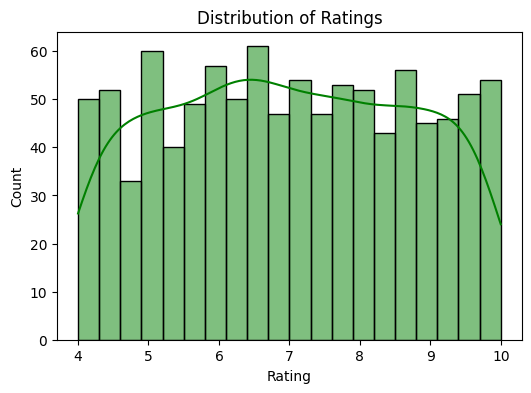

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot distribution of target variable Rating
plt.figure(figsize=(6,4)) #set the size of graph
sns.histplot(df_fe['Rating'], kde=True, bins=20, color="green") # set the graph how graph will be draw
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show() #display the graph


**Model** **Selection**


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df_fe.drop('Rating', axis=1)
y = df_fe['Rating']

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_test.shape


((800, 18), (200, 18))

**Train Model**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load your dataset
df = pd.read_csv("supermarket.csv")   # replace with your actual dataset file

#  Preprocess (here we just drop NA; adjust as needed)
df_fe = df.dropna()

# If you have categorical columns, encode them
df_fe = pd.get_dummies(df_fe, drop_first=True)

# Features & Target
# Make sure "Rating" is your target column name
X = df_fe.drop('Rating', axis=1)
y = df_fe['Rating']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

# Train & Evaluate
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        "R2 Score": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    }

# Show results
results_df = pd.DataFrame(results).T
print(results_df)


                   R2 Score       MAE      RMSE
Linear Regression -0.323773  1.573994  1.868607
Decision Tree     -1.273326  2.008021  2.448736
Random Forest     -0.030261  1.370840  1.648484


**Graphical Represenataion**

    Actual  Predicted
0      7.6      7.541
1      8.6      6.926
2      7.6      7.328
3      7.4      6.761
4      7.5      7.208
5      7.3      6.849
6      8.7      7.353
7      6.6      7.721
8      8.2      6.540
9      4.9      7.328
10     4.8      6.983
11     4.6      7.564
12     4.8      6.810
13     6.1      6.805
14     6.4      6.547
15     5.7      6.387
16     8.5      6.537
17     5.4      7.160
18     7.3      6.011
19     9.2      7.330


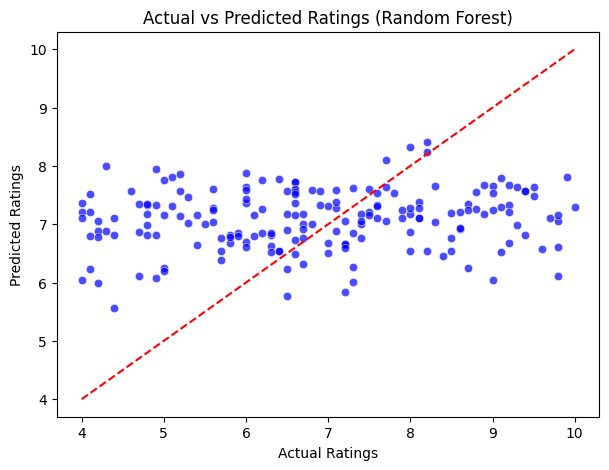

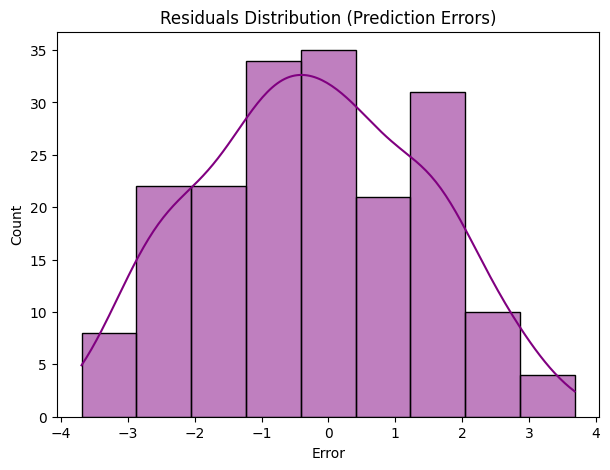

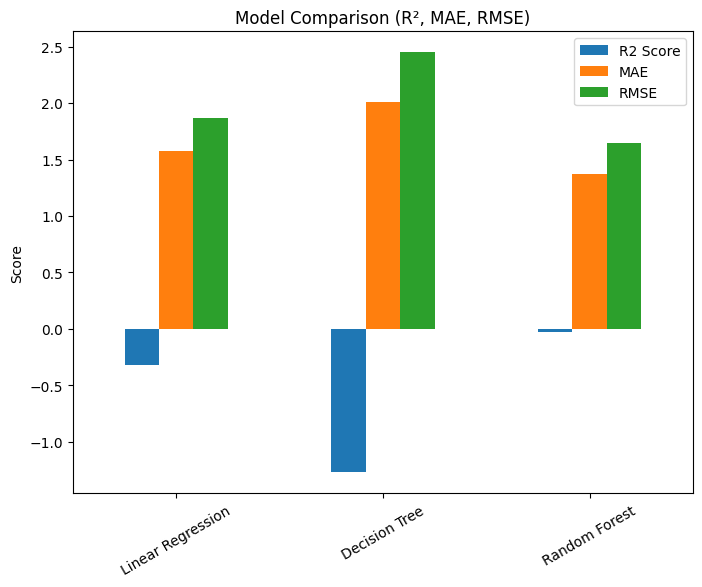

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#  1. Pick best model (Random Forest in this case)
best_model = RandomForestRegressor(random_state=42, n_estimators=100)
best_model.fit(X_train, y_train)

# 2. Predictions
y_pred = best_model.predict(X_test)

# 3. Compare Actual vs Predicted in Table (first 20 values)
comparison = pd.DataFrame({"Actual": y_test.values[:20], "Predicted": y_pred[:20]})
print(comparison)

# 4. Scatter Plot (Actual vs Predicted)
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (Random Forest)")
plt.show()

# 5. Residual Plot (errors)
residuals = y_test - y_pred
plt.figure(figsize=(7,5))
sns.histplot(residuals, kde=True, color="purple")
plt.title("Residuals Distribution (Prediction Errors)")
plt.xlabel("Error")
plt.show()

# 6. Model Performance Graph
results_df.plot(kind="bar", figsize=(8,6))
plt.title("Model Comparison (R², MAE, RMSE)")
plt.ylabel("Score")
plt.xticks(rotation=30)
plt.show()
